# Part I – Discovering City Types
## Where should the lads go? 🍻 Finding the ultimate cheap party city

We sort the 780 cities in the digital nomad dataset into **city types**,
and use them to answer one question for one very specific audience.

## 1. Audience and question

**Our audience:** a group of friends in their early twenties planning a cheap, wild lads' holiday,
in the style of *The Hangover* or *The Inbetweeners*. They are not data people. They want a straight answer:

> **Which city, and which country, gives the most party for the least money, without being dangerous?**

| They care about | They do *not* care about |
|---|---|
| Low prices (living costs and beer) | Internet speed, coworking spaces |
| Nightlife | Press freedom, fragile states index |
| Things to do in the daytime | Costs for long-term expats |
| Being reasonably safe | |
| Being welcome as loud tourists | |
| Whether weed is legal | |

## 2. K-means or Archetypal Analysis?

| | K-means | Archetypal Analysis (AA) |
|---|---|---|
| Each city is… | in **exactly one** group | a **mix** of all types (e.g. 70 % type A, 30 % type B) |
| A type is described by… | the **average** city in the group (the centroid) | an **extreme** city on the edge of the data (the archetype) |
| Answers the question… | *"Which cities are similar?"* | *"What are the extremes, and how close is each city to them?"* |

**Our choice: AA.** The lads are not looking for *"a group of fairly cheap cities with fairly good nightlife"*.
They want **the most extreme combination** of low prices and a wild nightlife, and an archetype is exactly that extreme.
AA also gives every city a **share** of each archetype. The share of the party archetype becomes our **party score**,
which we can rank cities by. A K-means centroid is an average, so the extreme gets watered down.

We still run K-means as well, and compare the two with the Adjusted Rand Index (ARI) in section 8.

## 3. Data
### 3.0 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import nnls

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

### 3.1 Load the data
We rename `alpha-2` to `country`, so the tables are easier to read.

In [2]:
cities = pd.read_csv('https://sds-aau.github.io/SDS-master/M1/data/cities.csv')
cities = cities.rename(columns={'alpha-2': 'country'})
print(cities.shape)
cities.head()

(780, 25)


,place,country,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,...,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,...,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,...,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,...,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,...,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


### 3.2 Data quality checks
Before choosing features we check the data for problems.

In [3]:
print('Missing values:        ', cities.isna().sum().sum())
print('Duplicated cities:     ', cities.duplicated(['place', 'country']).sum())
print('coffee == beer, always:', (cities['coffee_in_cafe'] == cities['cost_beer']).all())
print('Cities with free beer: ', (cities['cost_beer'] == 0).sum())

Missing values:         0
Duplicated cities:      0
coffee == beer, always: True
Cities with free beer:  18


In [4]:
# racism should be a score between 0 and 1
cities['racism'].sort_values().tail(3)

191    1.000000e+00
47     1.000000e+00
518    1.818182e+28
Name: racism, dtype: float64

In [5]:
# free beer?
cities.loc[cities['cost_beer'] == 0, ['place', 'country', 'cost_nomad', 'cost_beer']].head()

,place,country,cost_nomad,cost_beer
17,New Taipei City,TW,2695.0,0.0
20,Tainan,TW,1398.0,0.0
125,Fez,US,2735.0,0.0
164,Denpasar,ID,1575.0,0.0
174,Surakarta,ID,565.0,0.0


In [6]:
# are the country codes right?
cities.loc[cities['place'].isin(['Fez', 'Hama']), ['place', 'country', 'region']]

,place,country,region
125,Fez,US,Americas
358,Hama,GB,Europe


**What we found**
- No missing values and no duplicated cities.
- `coffee_in_cafe` and `cost_beer` are **identical in every row**, so we only use `cost_beer`.
- `racism` should be between 0 and 1, but Samara has 1.8 × 10²⁸, which is clearly a data error. We do not use `racism`, so it does not matter here.
- **18 cities have a beer price of exactly 0.** Free beer is not realistic, so these are missing values stored as 0.
  With free beer they would look like perfect party cities, so we **remove these 18 cities**.
- Some **country codes are wrong**: Fez (Morocco) is coded `US` and Hama (Syria) is coded `GB`.
  Fez is one of the 18 free-beer cities, so it is removed anyway. We fix Hama by hand.

In [7]:
cities = cities[cities['cost_beer'] > 0].reset_index(drop=True)
cities.loc[cities['place'] == 'Hama', 'country'] = 'SY'
print('Cities left:', len(cities))

Cities left: 762


### 3.3 Choosing the features
We only use columns that matter to the lads:

| Feature | Why | What the lads want |
|---|---|---|
| `cost_nomad` | Total cost of staying in the city (USD / month) | Low |
| `cost_beer` | Price of a beer (USD) | Low |
| `nightlife` | The core of the trip | High |
| `leisure` | Things to do in the daytime | High |
| `safety` | They want to come home again | Not too low |
| `friendly_to_foreigners` | Loud tourists should be welcome | High |
| `weed` | It is a *wild* trip (1 = legal, 0 = not) | Up to them |

In [8]:
features = ['cost_nomad', 'cost_beer', 'nightlife', 'leisure', 'safety', 'friendly_to_foreigners', 'weed']
cities[features].describe().round(2)

,cost_nomad,cost_beer,nightlife,leisure,safety,friendly_to_foreigners,weed
count,762.00,762.00,762.00,762.00,762.00,762.00,762.00
mean,2337.09,3.37,0.61,0.63,0.68,0.74,0.12
std,1083.45,1.94,0.23,0.20,0.21,0.18,0.32
min,387.00,0.09,0.00,0.00,0.00,0.00,0.00
25%,1488.50,1.72,0.40,0.60,0.60,0.60,0.00
50%,2215.50,3.15,0.60,0.60,0.60,0.80,0.00
75%,3068.50,4.73,0.80,0.80,0.80,0.80,0.00
max,6345.00,13.72,1.00,1.00,1.00,1.00,1.00


**Worth knowing**
- `cost_nomad` and `cost_beer` are quite strongly correlated, so price counts roughly twice. That is fine, because price is the lads' most important criterion.
- `weed` is a yes/no column, and only about 12 % of the cities have a 1. It will probably get its own type, and for this audience that is a feature, not a bug.

### 3.4 Scaling
`cost_nomad` is in thousands of dollars, while most scores are between 0 and 1.
Without scaling, `cost_nomad` would decide everything, so we standardise every feature to mean 0 and standard deviation 1.

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(cities[features])
X.shape

(762, 7)

## 4. Archetypal Analysis, by hand

AA describes every city as a **mix** of *k* archetypes, and every archetype as a **mix of real cities**.
The second rule keeps the archetypes on the edge of the data instead of outside it.
All mixing weights are ≥ 0 and add up to 1.

**Recipe** (similar to K-means by hand in the lecture)
1. **Start:** pick *k* random cities as the first archetypes
2. **Mix:** find the best mix of archetypes for every city
3. **Move:** find the archetypes that fit those mixes best, then pull them back to a mix of real cities
4. Repeat 2 and 3 until the error stops falling

We run the recipe from several random starts (`n_init`) and keep the best result, just like `KMeans(n_init=10)`.

In [10]:
def mix_weights(points, corners, M=200):
    """For every point: weights >= 0 that sum to 1, so that the weighted mix of the corners is as close as possible.
    The extra row of M's is a trick that forces the weights to sum to 1."""
    lhs = np.vstack([corners.T, M * np.ones(len(corners))])
    W = np.array([nnls(lhs, np.append(p, M))[0] for p in points])
    return W / W.sum(axis=1, keepdims=True)


def archetypal_analysis(X, k, n_init=5, max_iter=200, random_state=42):
    """Returns the archetypes (k x features), each city's mix of archetypes (cities x k) and the error (RSS)."""
    rng = np.random.default_rng(random_state)
    best = None
    for _ in range(n_init):
        Z = X[rng.choice(len(X), k, replace=False)]                 # 1. start: k random cities
        rss_old = np.inf
        for _ in range(max_iter):
            A = mix_weights(X, Z)                                   # 2. mix: each city as a mix of archetypes
            Z_free = np.linalg.lstsq(A, X, rcond=None)[0]           # 3. move: best archetypes for these mixes...
            Z = mix_weights(Z_free, X) @ X                          #    ...pulled back to a mix of real cities
            rss = ((X - A @ Z) ** 2).sum()
            if rss_old - rss < 1e-6 * rss_old:                      # 4. stop when the error stops falling
                break
            rss_old = rss
        A = mix_weights(X, Z)
        rss = ((X - A @ Z) ** 2).sum()
        if best is None or rss < best[2]:
            best = (Z, A, rss)
    return best

## 5. How many city types?

We try k = 2 to 8 with both methods:
- **K-means:** elbow method (inertia) and silhouette score, as in the lecture.
- **AA:** the share of the variation in the data that the archetypes explain. More archetypes always explain more,
  so we look for the point where one more stops adding much.

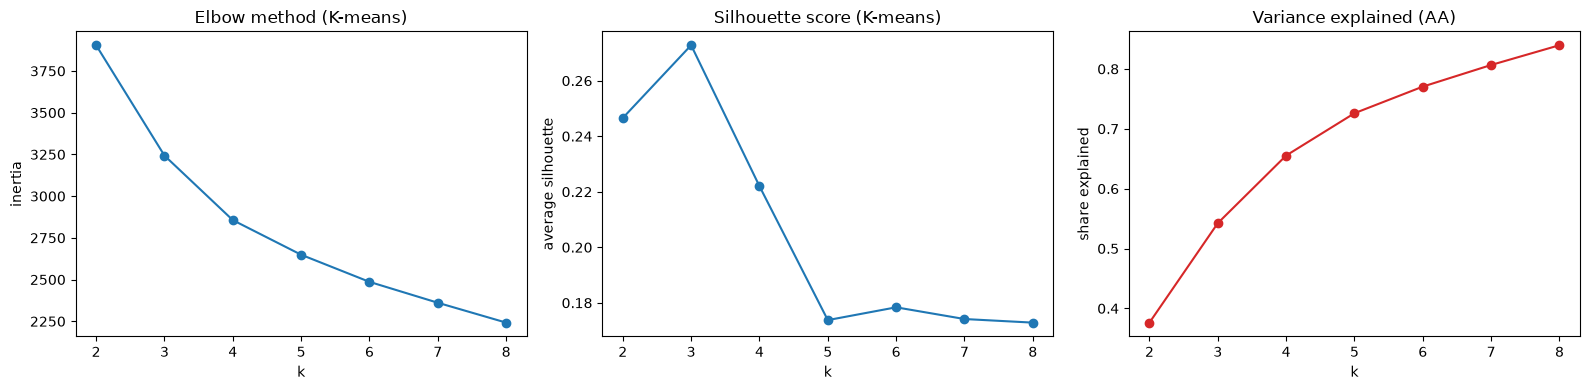

,k,inertia,silhouette,AA explained
0,2,3904.241,0.247,0.376
1,3,3242.868,0.273,0.542
2,4,2856.171,0.222,0.655
3,5,2648.784,0.174,0.726
4,6,2486.245,0.178,0.770
5,7,2361.118,0.174,0.807
6,8,2242.047,0.173,0.840


In [11]:
ks = range(2, 9)
total_ss = ((X - X.mean(axis=0)) ** 2).sum()
inertia, sil, aa_explained = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

    _, _, rss = archetypal_analysis(X, k)
    aa_explained.append(1 - rss / total_ss)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(ks, inertia, marker='o')
axes[0].set(title='Elbow method (K-means)', xlabel='k', ylabel='inertia')
axes[1].plot(ks, sil, marker='o')
axes[1].set(title='Silhouette score (K-means)', xlabel='k', ylabel='average silhouette')
axes[2].plot(ks, aa_explained, marker='o', color='tab:red')
axes[2].set(title='Variance explained (AA)', xlabel='k', ylabel='share explained')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': ks, 'inertia': inertia, 'silhouette': sil, 'AA explained': aa_explained}).round(3)

**How to read it**
- The **elbow** curve for K-means has no sharp bend.
- The **silhouette** is highest at k = 3, stays above 0.2 at k = 4, and then drops clearly at k = 5.
  The values are low overall, so the cities do not form sharply separated clumps. They lie on smooth gradients,
  which supports our choice of AA: it describes cities as mixes instead of forcing them into boxes.
- For **AA**, going from 3 to 4 archetypes still adds about 11 percentage points of explained variance. After that the gains get smaller.

**We choose k = 4** for both methods. It is the last k before the silhouette drops, and 4 types are few enough for the lads to remember.

## 6. Fitting both methods with k = 4

### 6.1 Archetypal Analysis
The archetypes come out as numbers 0–3. We give them names with a simple rule, so the names still fit if the order changes:
the archetype with the most weed is the weed type, the most expensive of the rest is the pricey type,
the one with the best nightlife of the rest is the party type, and the last one is the quiet type.

In [12]:
k = 4
Z, A, rss = archetypal_analysis(X, k, n_init=10)


def name_types(profile, names):
    """Name the types with the rule above. profile: one row per type, in real units."""
    left = list(profile.index)
    labels = {}
    for key, column in [('weed', 'weed'), ('pricey', 'cost_nomad'), ('party', 'nightlife')]:
        best = profile.loc[left, column].idxmax()
        labels[best] = names[key]
        left.remove(best)
    labels[left[0]] = names['quiet']
    return labels


aa_names = {'party': 'Party Paradise', 'weed': 'Weed-Friendly Party', 'pricey': 'Posh & Pricey', 'quiet': 'Rough & Boring'}
aa_profile = pd.DataFrame(scaler.inverse_transform(Z), columns=features)
aa_labels = name_types(aa_profile, aa_names)
aa_profile.index = aa_profile.index.map(aa_labels)

# every city's share of each archetype, and its largest archetype
shares = pd.DataFrame(A, columns=aa_profile.index)
cities['aa_type'] = shares.idxmax(axis=1)
cities['party_score'] = shares['Party Paradise']

aa_profile['cities'] = cities['aa_type'].value_counts()
aa_profile['most common region'] = cities.groupby('aa_type')['region'].agg(lambda r: r.mode()[0])
aa_profile.loc[list(aa_names.values())].round(2)

,cost_nomad,cost_beer,nightlife,leisure,safety,friendly_to_foreigners,weed,cities,most common region
Party Paradise,1577.79,1.59,0.93,0.96,0.80,1.00,0.0,327,Europe
Weed-Friendly Party,2749.71,3.98,0.82,0.77,0.67,0.90,1.0,90,Americas
Posh & Pricey,6150.87,10.35,0.58,0.60,0.96,0.78,-0.0,95,Europe
Rough & Boring,1043.32,0.90,0.20,0.20,0.32,0.34,0.0,250,Asia


**The four archetypes**
- 🍻 **Party Paradise:** cheap to live (about \$1,600 / month), beer around \$1.60, top nightlife and daytime fun, safe, very welcoming.
- 🌿 **Weed-Friendly Party:** weed is legal and the nightlife is good, but it costs almost twice as much as Party Paradise.
- 💸 **Posh & Pricey:** safe, but over \$6,000 a month and beer at around \$10. Wrong trip for the lads.
- 🥱 **Rough & Boring:** the cheapest, but little nightlife, low safety and not very welcoming.

The *party score* of a city is its share of **Party Paradise**. It is the score we rank cities by in section 7.

### 6.2 K-means
We name the K-means clusters with the same rule, so the two methods are easy to compare.

In [13]:
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)

km_names = {'party': 'Cheap & Lively', 'weed': 'Weed-Friendly', 'pricey': 'Pricey', 'quiet': 'Cheap & Quiet'}
km_profile = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=features)
km_labels = name_types(km_profile, km_names)
km_profile.index = km_profile.index.map(km_labels)
cities['km_type'] = pd.Series(km.labels_).map(km_labels)

km_profile['cities'] = cities['km_type'].value_counts()
km_profile.loc[list(km_names.values())].round(2)

,cost_nomad,cost_beer,nightlife,leisure,safety,friendly_to_foreigners,weed,cities
Cheap & Lively,1724.24,2.06,0.72,0.77,0.67,0.84,0.0,155
Weed-Friendly,2816.87,4.20,0.70,0.69,0.69,0.81,1.0,91
Pricey,3228.18,5.11,0.70,0.69,0.84,0.80,-0.0,250
Cheap & Quiet,1692.58,2.22,0.43,0.48,0.54,0.59,-0.0,266


The K-means types look similar, but they are **averages**. The "Cheap & Lively" centroid has a nightlife of about 0.7,
while the AA "Party Paradise" archetype is close to the maximum (about 0.9). K-means describes the middle of a group, and AA describes its extreme.

## 7. Visualising the result for the lads

We follow the storytelling ideas from the lecture: **one message per chart, written as the title**, the party type
highlighted in orange, and everything else toned down.

We use the same colours in all charts:

In [14]:
colours = {'Party Paradise': 'tab:orange', 'Weed-Friendly Party': 'tab:green',
           'Posh & Pricey': 'tab:purple', 'Rough & Boring': 'lightgrey',
           'Cheap & Lively': 'tab:orange', 'Weed-Friendly': 'tab:green',
           'Pricey': 'tab:purple', 'Cheap & Quiet': 'lightgrey'}

### 7.1 Radar chart: which region parties the most?
Each line is a region, and each corner is an archetype. The further out a line goes towards a corner,
the more the cities in that region look like that archetype (the average share).

In [15]:
region_mix = shares.groupby(cities['region']).mean()[list(aa_names.values())]
region_mix['cities'] = cities['region'].value_counts()
region_mix.round(2)

,Party Paradise,Weed-Friendly Party,Posh & Pricey,Rough & Boring,cities
region,,,,,
Africa,0.33,0.03,0.15,0.49,44
Americas,0.35,0.20,0.22,0.23,220
Asia,0.41,0.01,0.12,0.45,246
Europe,0.39,0.13,0.25,0.23,235
Oceania,0.53,0.00,0.35,0.11,17


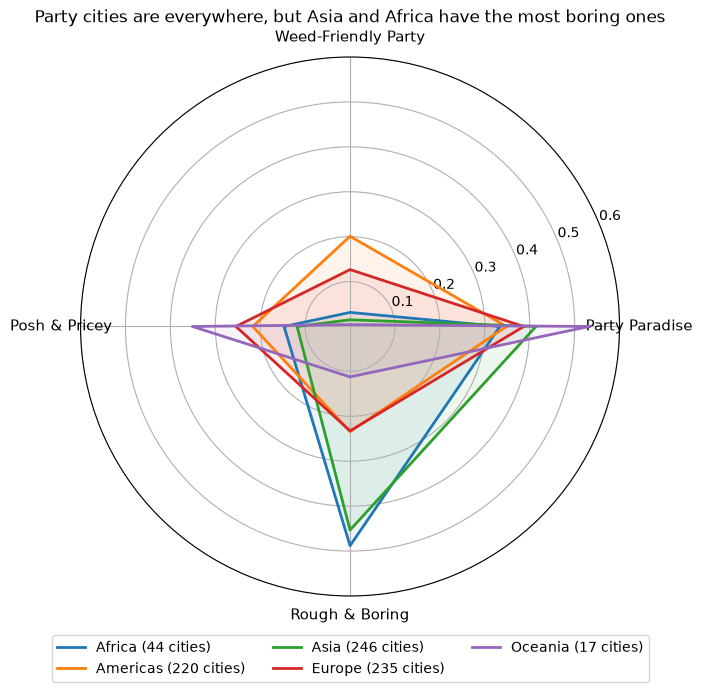

In [16]:
types = list(aa_names.values())
angles = np.linspace(0, 2 * np.pi, len(types), endpoint=False).tolist()
angles += angles[:1]                                     # close the circle

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for region, row in region_mix[types].iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, label=f'{region} ({region_mix.loc[region, "cities"]} cities)')
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(types, fontsize=11)
ax.set_ylim(0, 0.6)
ax.set_title('Party cities are everywhere, but Asia and Africa have the most boring ones', pad=25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=3)
plt.show()

**What it shows**
- **Party Paradise** is the biggest or second-biggest type in **every** region. You can find a cheap party almost anywhere.
- **Asia** and **Africa** lean the most towards **Rough & Boring**, so the lads have to pick the right city there.
- **Weed-Friendly Party** belongs to the **Americas** and **Europe** (legal weed in parts of North America and e.g. the Netherlands).
- **Oceania** has the highest party share, but only 17 cities, and they are expensive, so we do not trust it as much.

### 7.2 Top 10: the ultimate cheap party cities
The party score works like the **target** in a supervised problem: it is the one number we want as high as possible.
We rank all cities by it and show the top 10.

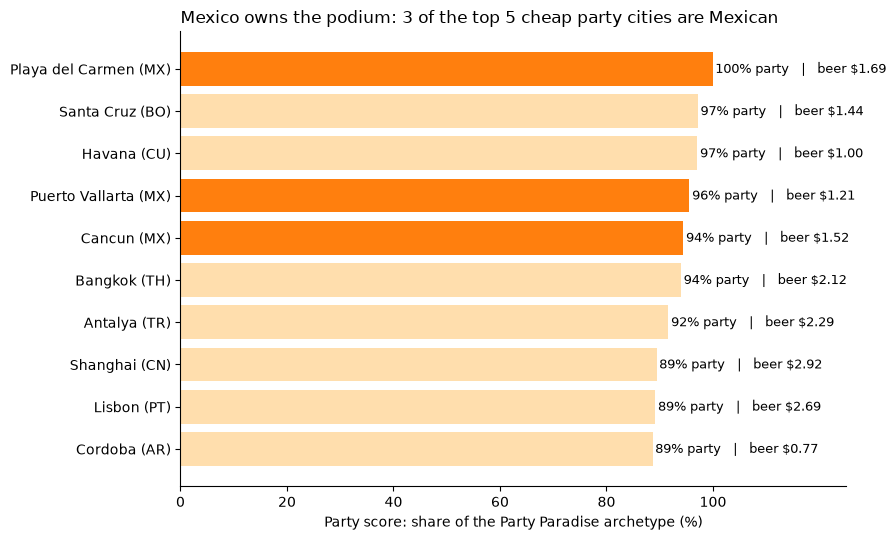

In [17]:
top10 = cities.nlargest(10, 'party_score').iloc[::-1]          # reversed, so number 1 is at the top
labels = top10['place'] + ' (' + top10['country'] + ')'
bar_colours = ['tab:orange' if c == 'MX' else 'navajowhite' for c in top10['country']]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(labels, top10['party_score'] * 100, color=bar_colours)
for y, (score, beer) in enumerate(zip(top10['party_score'], top10['cost_beer'])):
    ax.text(score * 100 + 0.5, y, f'{score:.0%} party   |   beer ${beer:.2f}', va='center', fontsize=9)
ax.set_xticks(range(0, 101, 20))
ax.set(xlim=(0, 125), xlabel='Party score: share of the Party Paradise archetype (%)')
ax.set_title('Mexico owns the podium: 3 of the top 5 cheap party cities are Mexican', loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# which countries have the most cities in the top 20?
cities.nlargest(20, 'party_score')['country'].value_counts().head(5)

country
MX    4
TH    3
KR    2
BO    1
CU    1
Name: count, dtype: int64

### 7.3 Scatter plot: K-means vs. AA
Price against nightlife for every city, coloured by type. The black **X**'s are the K-means centroids, and the black **stars** are the AA archetypes.
Nightlife only takes a few values (0, 0.2, 0.4 …), so we add a little random jitter to make the dots visible.

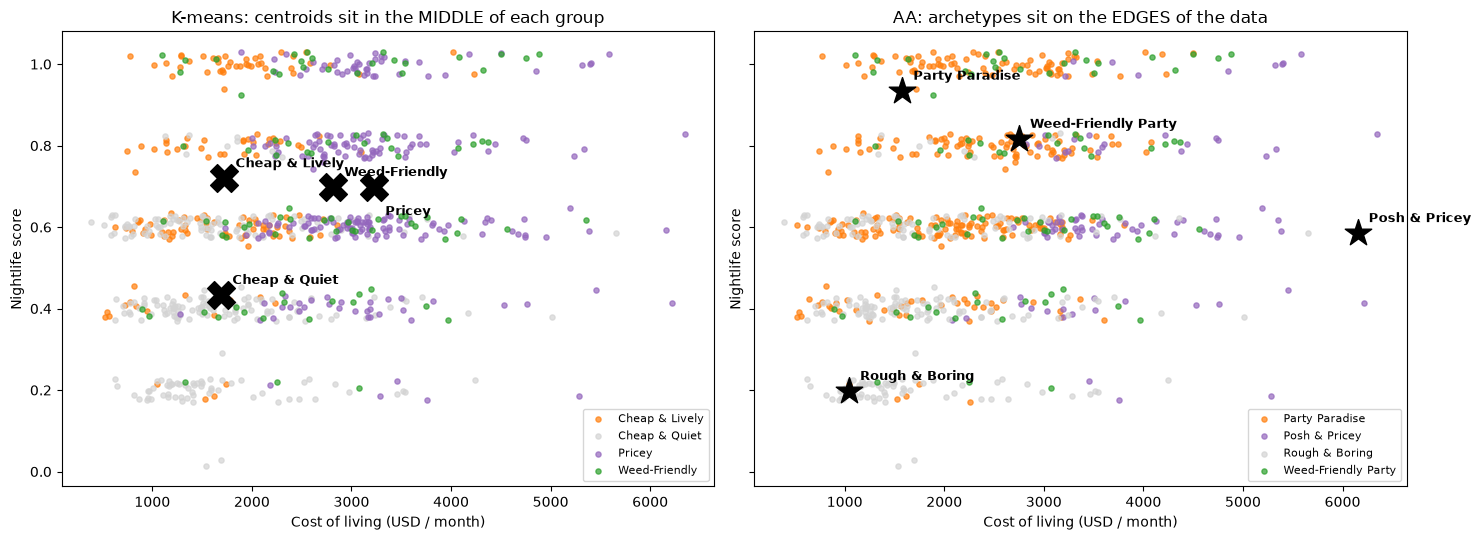

In [19]:
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.03, 0.03, len(cities))
aa_points = aa_profile.loc[types, ['cost_nomad', 'nightlife']]
km_points = km_profile.loc[list(km_names.values()), ['cost_nomad', 'nightlife']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True)
for ax, column, points, marker, title in [
        (axes[0], 'km_type', km_points, 'X', 'K-means: centroids sit in the MIDDLE of each group'),
        (axes[1], 'aa_type', aa_points, '*', 'AA: archetypes sit on the EDGES of the data')]:
    for name, group in cities.groupby(column):
        ax.scatter(group['cost_nomad'], group['nightlife'] + jitter[group.index],
                   color=colours[name], s=14, alpha=0.7, label=name)
    ax.scatter(points['cost_nomad'], points['nightlife'], marker=marker, s=400, color='black')
    for name, (x, y) in points.iterrows():
        offset = (8, -20) if name == 'Pricey' else (8, 8)          # keep the two labels apart
        ax.annotate(name, (x, y), xytext=offset, textcoords='offset points', fontsize=9, fontweight='bold')
    ax.set(title=title, xlabel='Cost of living (USD / month)', ylabel='Nightlife score')
    ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

The K-means **X**'s sit inside their groups, while the AA **stars** sit out on the edges. Party Paradise lies top left:
**cheap and maximum nightlife**. That corner is exactly what the lads are looking for, and it is the reason we chose AA.

## 8. Comparing the methods: Adjusted Rand Index
To compare, each city gets its **largest** archetype (e.g. 70 % Party Paradise → Party Paradise).
ARI then measures how much the two methods agree on *which cities belong together*: 1 = identical groups, 0 = no better than chance.

In [20]:
ari = adjusted_rand_score(cities['km_type'], cities['aa_type'])
print(f'ARI = {ari:.2f}')

pd.crosstab(cities['km_type'], cities['aa_type'], rownames=['K-means'], colnames=['AA'])

ARI = 0.53


AA,Party Paradise,Posh & Pricey,Rough & Boring,Weed-Friendly Party
K-means,,,,
Cheap & Lively,155,0,0,0
Cheap & Quiet,29,0,237,0
Pricey,143,94,13,0
Weed-Friendly,0,1,0,90


In [21]:
# and for the question the lads actually asked: how does K-means label AA's top 20 party cities?
cities.nlargest(20, 'party_score')['km_type'].value_counts()

km_type
Cheap & Lively    20
Name: count, dtype: int64

**What it shows**
- **ARI ≈ 0.53: moderate agreement.** The methods find roughly the same structure, but not the same groups.
- They **agree** on the weed cities (almost the same ~90 cities), and mostly on the rough and boring ones.
- They **disagree** mainly about mid-priced cities with good nightlife. AA calls most of them *Party Paradise*,
  because they are closest to that corner, while K-means puts many of them in *Pricey*, because they are near its average.
- For the lads' question they agree completely: **all of AA's top 20 party cities are in K-means' "Cheap & Lively" group.**

## 9. Decision: keep AA, switch, or no real difference?

**The difference is not substantial for our question, so we keep AA.**
Both methods point to the same winners, so switching to K-means would not change the recommendation.
But only AA gives us what the story needs: a **party score** to rank cities by, and a **mix** for every city and region.
K-means can only tell us that a city is "in the lively group", not how close it is to the ultimate party city.

## 10. The story: where should the lads go?

### We found four kinds of cities
| Type | In one sentence | For the lads |
|---|---|---|
| 🍻 **Party Paradise** | Cheap, beer around \$1.60, top nightlife, safe and welcoming | **Go here** |
| 🌿 **Weed-Friendly Party** | Legal weed and good nightlife, but almost twice the price | Only if weed is a must, and the budget allows |
| 💸 **Posh & Pricey** | Safe, but \$6,000+ a month and \$10 beers | The budget is gone after two nights |
| 🥱 **Rough & Boring** | Cheapest, but nothing to do and not very safe | Cheap for a reason, so skip it |

### 🏆 And the winner is… Mexico
- **3 of the top 5** cheap party cities are Mexican: **Playa del Carmen** (the closest city to the pure party archetype), **Puerto Vallarta** and **Cancún**.
- Beer costs about **\$1.20–1.70**, and safety scores are good for a party city.
- Playa del Carmen and Cancún are only about an hour apart on the Caribbean coast, so the lads can easily do both on one trip.

### 🥈 Plan B: Thailand
**Bangkok** (yes, *The Hangover Part II*) and **Ko Samui** are both in the top 15, with beer around \$1.40–2.10.
It is a long flight, but it is very cheap once they are there.

### 🥉 Staying in Europe?
**Lisbon** is in the top 10, and **Belgrade** is the cheapest European city near the top (about \$1,000 / month and beer around \$1.35).

### What the lads should know (limitations)
- The data comes from **digital nomads**, not tourists on a one-week trip, so prices and scores reflect long stays.
- We removed **18 cities** with a beer price of 0, including Denpasar on Bali, so a few good party places may be missing.
- Most scores only take the values 0, 0.2, 0.4 … 1, so small differences between cities should not be taken too seriously.
- The party score measures how *close* a city is to the ideal. It is not a guarantee of a good trip.